In [13]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [14]:
sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp


sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_project")
from plot_data import *
from process_data import *


sys.path.insert(0, "/lustre/lrspec/users/4301/snidpy/sourcepy")
from apodize import *
from logwave import Logwave as lw 
from logwave import log_rebin

In [15]:
folder_list = ["kinney_sample1", "kinney_sample2", "kinney_sample3", "kinney_sample4", "kinney_sample5",
               "kinney_sample6", "kinney_sample7", "kinney_sample8", "kinney_sample9",
               "kinney_sample10", "kinney_sample11", "kinney_sample12", "kinney_sample13",
               "kinney_sample14"]
folder_list = ["kinney_sample14"]

save_dir = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/folder_parquet"

for folder in tqdm(folder_list):
    filenames = sorted(glob.glob("/lustre/lrspec/users/4301/Milligan_ABC-SN/data/"+ folder +"/*"))
    file_info = [name.split("/")[-1] for name in filenames]
    df_metadata = pd.DataFrame(file_info, columns=["filename"])
    df_metadata[["host", "sn_type", "redshift", "SN_mag", "host_mag"]] = [get_filename_info(info) for info in file_info]
    df_metadata[ "host_mag"] = df_metadata[ "host_mag"].astype(float)
    df_metadata[ "redshift"] = df_metadata[ "redshift"].astype(float)
    df_metadata[ "SN_mag"] = df_metadata[ "SN_mag"].astype(float)

    # set up to extract the X values 
    num_wvl = 23411
    dat_size = len(df_metadata)
    plots = False
    
    X_all = np.zeros((dat_size, num_wvl))
    ABC_IDs = np.zeros((dat_size)) # classification as the float classifier
    Mill_IDs = np.zeros((dat_size)) # classification as the float classifier

    # extract flux and wavelength values from each file 
    for i, filename in enumerate(filenames):
        sep = " " # Define separator for reading data
        s = pd.read_csv(filename, sep=sep, header=None, comment="#") # Read the spectrum data
        wave = s[0]
        X_all[i] = s[1]

        # getting data 
        ABC_type, Mill_type = get_ABC_Mill_type(df_metadata["sn_type"].iloc[i])
        ABC_IDs[i] = ABC_type
        Mill_IDs[i] = Mill_type
        

    # combining metadata and spectra data into single df
    df_metadata["ABC_type"] = ABC_IDs
    df_metadata["Mill_type"] = Mill_IDs    
    df_metadata["Spectral Phase"] = np.zeros((dat_size))
    df_spec = pd.DataFrame(X_all, columns = wave)
    df_folder = pd.concat([df_metadata, df_spec], axis=1)
    df_folder = df_folder.drop(["filename"], axis = 1)


    


100%|██████████| 1/1 [00:04<00:00,  4.05s/it]


Text(0.5, 1.0, 'orginal data unprocessed')

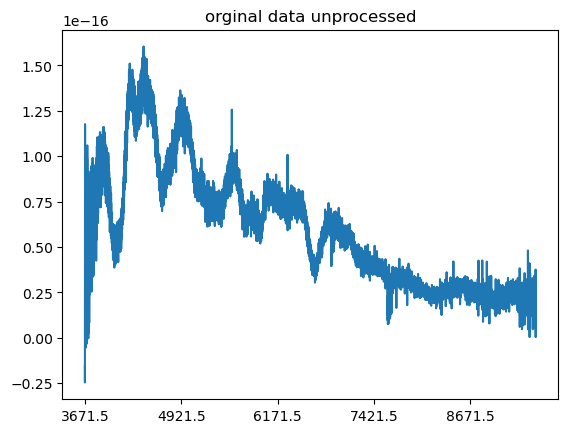

In [16]:
df_folder.loc[0].iloc[8:].T.plot()
plt.title("orginal data unprocessed")

In [17]:
print(min(wave), max(wave))

3671.5 9524.0


/home/4301/miniconda3/envs/abc-env/lib/python3.10/site-packages/pandas/io/parquet.py:191: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = self.api.Table.from_pandas(df, **from_pandas_kwargs)


Text(0.5, 1.0, 'orginal data preprocessed')

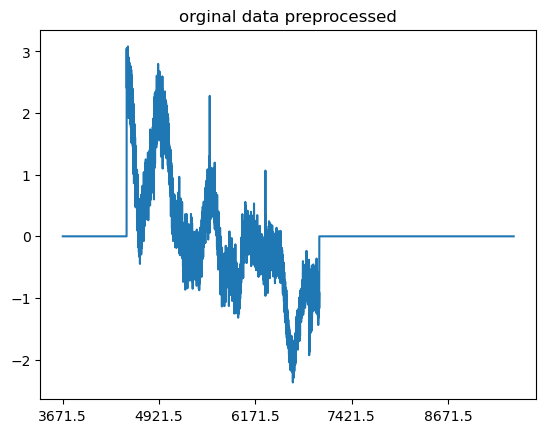

In [18]:
phase_range=(-20, 50)
ptp_range=(-np.inf, np.inf)
wvl_range=(4500, 7000)
save_dir_original_R  = save_dir
# note preproccess_dataframe does alter orginal dataframe
df_prep = preproccess_dataframe(df_folder, phase_range, ptp_range, wvl_range)
df_prep.to_parquet(os.path.join(save_dir_original_R, folder + "_preprocessed.parquet"))

df_folder.loc[0].iloc[8:].T.plot()
plt.title("orginal data preprocessed")

In [19]:
from scipy.interpolate import interp1d

def interp_flux_logspace(log_wave, wvl0, fluxes0):
    # fluxes0 shape: (N_spectra, N_wavelengths)
    f = interp1d(wvl0, fluxes0, axis=1, bounds_error=False, fill_value=0.0)
    return f(log_wave)

In [20]:
# code from degrade_dataframe
R = 100
data = dp.extract_dataframe(df_prep)
index = data[0]  # SN Name for each spectrum
wvl0 = data[1]  # Wavelength array
flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
df_metadata = data[5]  # Sub-dataframe containing only the metadata
fluxes0 = data[6]  # Only the flux values in a numpy array

# need to change cadence and range of data points 
R_current = np.mean(wvl0[:-1] / np.diff(wvl0)) # current resolution
nw = dg.calc_num_wvl_bins(R_current, (2500, 10_000)) # number of wavelengths
w0, w1 = 2_500, 10_000 # wavelength range
log_wave, wvl0_bin_sizes = dg.calc_new_wvl(R_current, wvl0, (w0, w1)) 
flux = interp_flux_logspace(log_wave, wvl0, fluxes0) # from logwave  # need to vectorize this guy


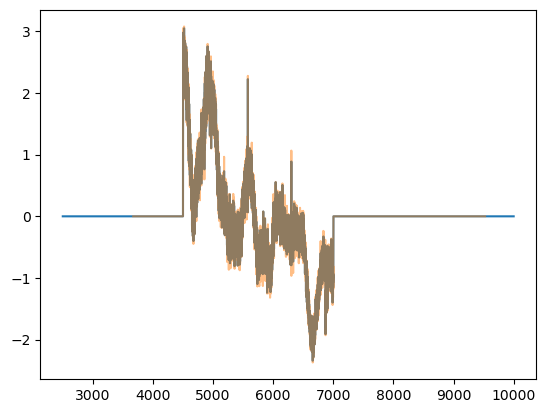

In [21]:
#shifted data to new wavelength axis but not degraded 
plt.plot(log_wave, flux[0])
plt.plot(wvl0, fluxes0[0], alpha =0.5)

In [42]:
flux[:50].shape

(50, 36586)

In [26]:
%%time
num_data_points = 10

## code from data_degrade.degrade_dataframe

# Perform degradation (i.e. lowers resolution) for each spectrum in the dataset. The function
# # degraded_spectrum is vectorized, so supplying multiple spectrum allows
# # the operation to be parallelized.
fluxes_convolve, wvl_degraded, fluxes_degraded = dg.degrade_spectrum(R, log_wave, flux[:num_data_points])

# `wvl_degraded` is actually multiple copies of the same wavelength array, 
# so we only need the first one.
degraded_flux_columns = wvl_degraded[0].astype(str)

# Store the convolution data (not the rebinned spectra)
sn_data_convolve = df_prep.copy(deep=True)
sn_data_convolve = sn_data_convolve.iloc[:num_data_points]
sn_data_convolve.loc[:, log_wave] = fluxes_convolve

# Store the rebinned spectra into its own dataframe.
df_fluxes_degraded = pd.DataFrame(data=fluxes_degraded,
                                  columns=degraded_flux_columns,
                                  index=index[:num_data_points],
                                  dtype=float)
sn_data_degraded = pd.concat([df_metadata.iloc[:num_data_points], df_fluxes_degraded], axis=1)

CPU times: user 21min 4s, sys: 364 ms, total: 21min 4s
Wall time: 21min 5s


In [27]:
sn_data_convolve.loc[:, flux0_columns].shape
fluxes_convolve.shape

(10, 36586)

In [2]:
#shifted data to new wavelength axis but not degraded 
plt.plot(log_wave, fluxes_convolve[0])
# plt.plot(flux0_columns.astype(float), fluxes_convolve, alpha =0.5)
plt.plot(wvl_degraded[0], fluxes_degraded[0])

NameError: name 'plt' is not defined

In [32]:
wvl0.shape

(23411,)

In [33]:
fluxes0[0].shape

(23411,)

In [34]:
R_current = np.mean(wvl0[:-1] / np.diff(wvl0))
R_current

np.float64(26390.5)

In [38]:
wvl_range

(4500, 7000)

In [39]:
sn_data_convolve.to_parquet(os.path.join(save_dir_original_R, folder + "_convoloved.parquet"))

In [40]:
sn_data_degraded.to_parquet(os.path.join(save_dir_original_R, folder + "_rebinned.parquet"))

In [41]:
%%time
num_data_points = 1

## code from data_degrade.degrade_dataframe

# Perform degradation (i.e. lowers resolution) for each spectrum in the dataset. The function
# # degraded_spectrum is vectorized, so supplying multiple spectrum allows
# # the operation to be parallelized.
fluxes_convolve, wvl_degraded, fluxes_degraded = dg.degrade_spectrum(R, log_wave, flux[:num_data_points])

# `wvl_degraded` is actually multiple copies of the same wavelength array, 
# so we only need the first one.
degraded_flux_columns = wvl_degraded[0].astype(str)

# Store the convolution data (not the rebinned spectra)
sn_data_convolve = df_prep.copy(deep=True)
sn_data_convolve = sn_data_convolve.iloc[:num_data_points]
sn_data_convolve.loc[:, log_wave] = fluxes_convolve

# Store the rebinned spectra into its own dataframe.
df_fluxes_degraded = pd.DataFrame(data=fluxes_degraded,
                                  columns=degraded_flux_columns,
                                  index=index[:num_data_points],
                                  dtype=float)
sn_data_degraded = pd.concat([df_metadata.iloc[:num_data_points], df_fluxes_degraded], axis=1)

CPU times: user 16min 50s, sys: 264 ms, total: 16min 50s
Wall time: 16min 51s
